# NASADEM

* **Products used:** 
[nasadem](http://localhost:81/products/nasadem)

Notebook modified from https://github.com/opendatacube/cube-in-a-box/tree/main/notebooks

## Background

NASADEM provides global topographic data at 1 arc-second (~30m) horizontal resolution, derived primarily from data captured via the [Shuttle Radar Topography Mission](https://www2.jpl.nasa.gov/srtm/) (SRTM).

## Important details

**Product details:**
* Product name in the datacube: `"nasadem"`
* `Elevation` product
* Spatial resolution: 30 m
* Date-range: 02/20/2000
* Universal Transverse Mercator (UTM) map projection. World Geodetic System (WGS) 84 datum
* Stored in Cloud-Optimised GeoTIFF Format (COG)

## Description

This notebook will run through loading in NASADEM Product images.
Topics covered include:

* Using the native `dc.load()` function to load in elevation data
* Compute hillshade and use it to enhance elevation display

***

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell.

### Load packages

In [1]:
import sys
sys.path.insert(1, '../utils/')

In [2]:
# reload module before executing code
%load_ext autoreload
%autoreload 2

import datacube
from utils.deafrica_plotting import display_map
from matplotlib.colors import LightSource
import matplotlib.pyplot as plt


from planetary_computer import sign_url  # needed to access planetary-computer collection

### Connect to the datacube

In [3]:
dc = datacube.Datacube(app='NASADEM')

## Describe product measurements

In [4]:
dc.list_measurements().loc['nasadem']

,name,dtype,units,nodata,aliases,flags_definition
measurement,,,,,,
elevation,elevation,int16,1,-32768,NaN,NaN


## Load NASADEM data from the datacube

As this product contains only a single integer band for a single time, and consequently is way lighter than other available products, we will process it the light way, meaning without Daskerization (as in other products notebooks).

In [5]:
# Configure a bounding box and visualize it
lat, lon = 25.69454,29.90937   # 22.821, 28.518
buffer = 0.1

display_map(x=(lon - buffer, lon + buffer), y=(lat + buffer, lat - buffer))

In [6]:
# Create a query object (we don't need to define time range and measurements as it is a
# single time and single band product)

query = {
    'product': 'nasadem',
    'x': (lon - buffer, lon + buffer),
    'y': (lat + buffer, lat - buffer),
    'output_crs': 'epsg:6933',
    'resolution':30,
    'patch_url': sign_url,
}

In [7]:
ds = dc.load(**query)
ds = ds.isel(time=0).drop('time')  # get rid of time dimension
print(ds)

<xarray.Dataset>
Dimensions:      (x: 644, y: 769)
Coordinates:
  * y            (y) float64 3.183e+06 3.183e+06 3.183e+06 ... 3.16e+06 3.16e+06
  * x            (x) float64 2.876e+06 2.876e+06 ... 2.895e+06 2.895e+06
    spatial_ref  int32 6933
Data variables:
    elevation    (y, x) int16 428 427 425 425 427 427 ... 562 562 563 563 563
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref


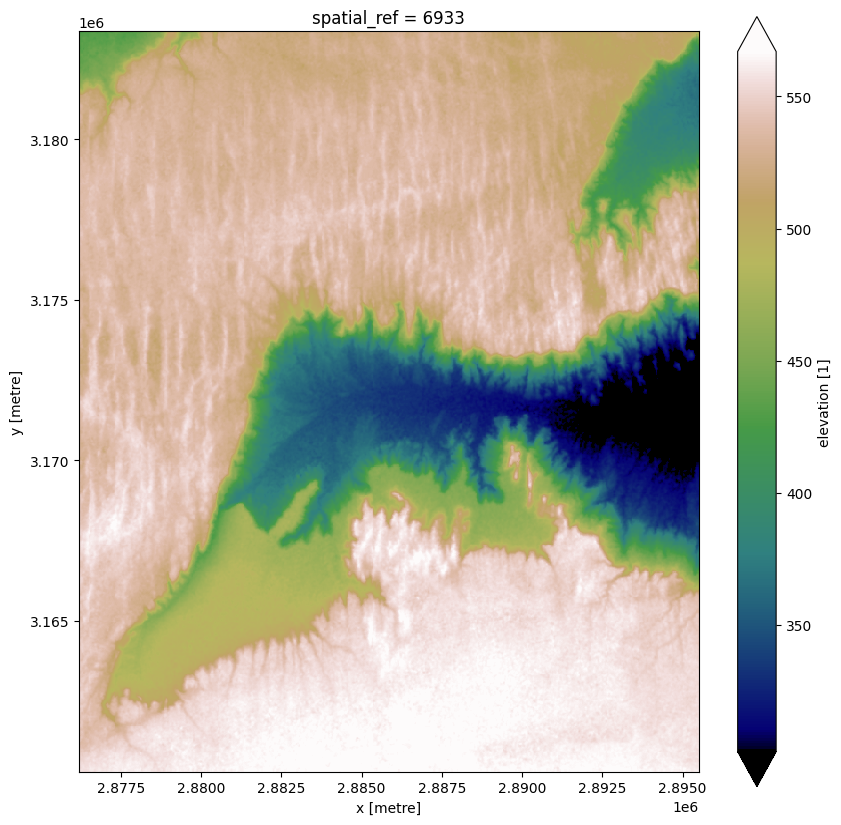

In [8]:
# Plot elevation with equal x and y resolution

plt.figure(figsize=(10, 10))
ds['elevation'].plot(robust=True, cmap='gist_earth')
plt.gca().set_aspect('equal')
plt.show()

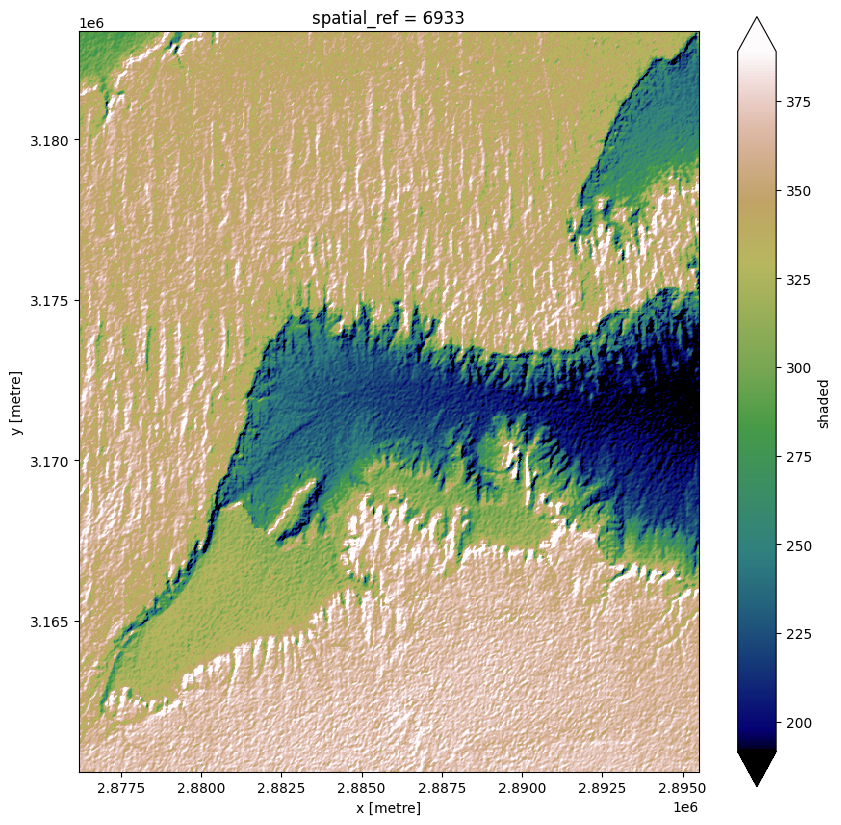

In [9]:
# Plot elevation with an hillshade overlay

elevation = ds.elevation.values
ls = LightSource(azdeg=315, altdeg=45)
dyx = 30
shade = ls.hillshade(elevation, vert_exag=0.5, dx=dyx, dy=dyx, fraction=1.0)
ds['shaded'] = (['y', 'x'], elevation * shade)

plt.figure(figsize=(10, 10))
ds['shaded'].plot(robust=True, cmap='gist_earth')
plt.gca().set_aspect('equal')
plt.show()

***

## Additional information

**License:** The code in this notebook is slighly modified from https://github.com/digitalearthafrica/deafrica-sandbox-notebooks and licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0).

**Compatible datacube version:**

In [10]:
print(datacube.__version__)

1.9.0


**Last tested:**

In [11]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2025-01-09'